Selected graph: QmbkDZuZh2dhK29UPvDa8neWehihzMejjjWH1oCD3ubTWi.pt


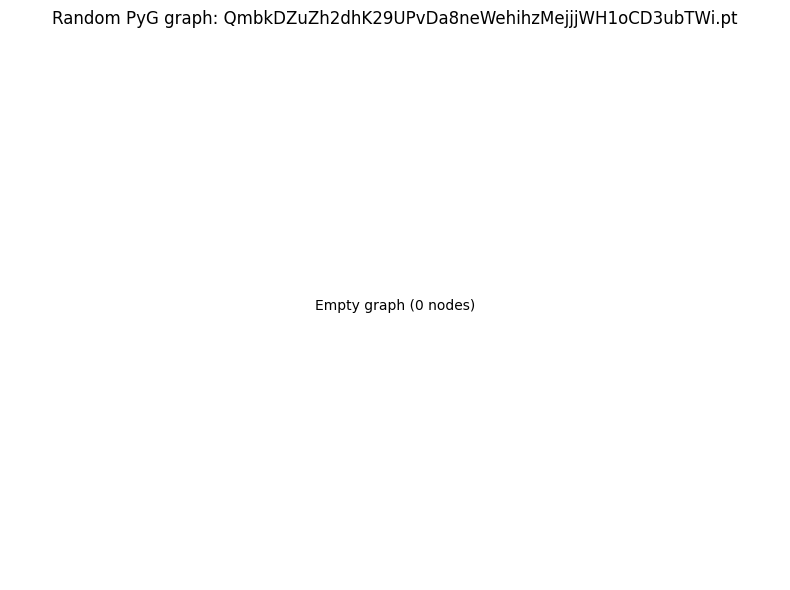

In [2]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import torch

# Find the graphs directory (works whether CWD is repo root or notebook folder)
possible_dirs = [
    Path("data/validation-small/graphs"),
    Path("../data/validation-small/graphs"),
    Path("../../data/validation-small/graphs"),
]
graph_dir = next((p.resolve() for p in possible_dirs if p.exists()), None)
if graph_dir is None:
    raise FileNotFoundError("Could not find data/validation-small/graphs from current working directory.")

pt_files = sorted(graph_dir.glob("*.pt"))
if not pt_files:
    raise FileNotFoundError(f"No .pt files found in {graph_dir}")

chosen = random.choice(pt_files)
print(f"Selected graph: {chosen.name}")

data = torch.load(chosen, map_location="cpu", weights_only=False)
if isinstance(data, dict) and "edge_index" in data:
    edge_index = data["edge_index"]
    pos = data.get("pos", None)
    x = data.get("x", None)
    explicit_num_nodes = data.get("num_nodes", None)
else:
    edge_index = data.edge_index
    pos = getattr(data, "pos", None)
    x = getattr(data, "x", None)
    explicit_num_nodes = getattr(data, "num_nodes", None)

if edge_index is None:
    raise ValueError("Loaded graph has no edge_index.")

if not torch.is_tensor(edge_index):
    edge_index = torch.as_tensor(edge_index)

if explicit_num_nodes is not None:
    num_nodes = int(explicit_num_nodes)
elif pos is not None and hasattr(pos, "shape") and len(pos.shape) >= 1:
    num_nodes = int(pos.shape[0])
elif x is not None and hasattr(x, "shape") and len(x.shape) >= 1:
    num_nodes = int(x.shape[0])
elif edge_index.numel() == 0:
    num_nodes = 0
else:
    num_nodes = int(edge_index.max(dim=1).values.max().item()) + 1

G = nx.Graph()
G.add_nodes_from(range(num_nodes))
if edge_index.numel() > 0:
    G.add_edges_from(edge_index.t().tolist())

if pos is not None:
    pos_tensor = pos.detach().cpu() if hasattr(pos, "detach") else pos
    if len(pos_tensor.shape) >= 2 and pos_tensor.shape[1] >= 2:
        draw_pos = {i: (float(pos_tensor[i, 0]), float(pos_tensor[i, 1])) for i in range(min(num_nodes, pos_tensor.shape[0]))}
        for i in range(num_nodes):
            draw_pos.setdefault(i, (0.0, 0.0))
    else:
        draw_pos = nx.spring_layout(G, seed=42)
else:
    draw_pos = nx.spring_layout(G, seed=42)

node_color = "skyblue"
if x is not None:
    x_tensor = x.detach().cpu() if hasattr(x, "detach") else x
    if len(x_tensor.shape) == 2 and x_tensor.shape[1] > 0:
        node_color = x_tensor[:, 0].numpy()

plt.figure(figsize=(8, 6))
if num_nodes == 0:
    plt.text(0.5, 0.5, "Empty graph (0 nodes)", ha="center", va="center")
    plt.axis("off")
else:
    nx.draw(
        G,
        pos=draw_pos,
        node_size=80,
        node_color=node_color,
        cmap="viridis",
        edge_color="#888888",
        with_labels=False,
    )

plt.title(f"Random PyG graph: {chosen.name}")
plt.tight_layout()
plt.show()